In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision # official pytorch library specifically for computer vision
from torchvision.datasets import CIFAR10

In [27]:
# datasets & dataloader
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# image => scale (0,1) => normalize => scale (-1,1)
transform = transforms.Compose([
transforms.ToTensor(), # transform all images to pytorch tensor + scale all images
transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # it normalize image in range (-1,1)  (),() is std deviation and mean
])   # with this we specifies the transformations that we are going to apply on all images

train_set = CIFAR10(root="./data",train=True,download=True,transform=transform)
test_set = CIFAR10(root = './data',train=False,download=True,transform=transform)

In [28]:
train_set

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [29]:
train_loader = DataLoader(train_set,batch_size=64,shuffle=True)
test_loader = DataLoader(test_set,batch_size=64)

### Build the CNN

In [30]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1,stride=1), # input size = 3 because there will be three matrix for one image in input one for red one for green one for blue and output_channels means = how many filters(kernals) we want to apply in convolutional layer lets startwith 32 and double later and since we are applying 32 filters we will get 32 feature maps in output that will be input for next cconvolutional layer and so on 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),

            nn.Conv2d(in_channels=32,out_channels=64, kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),

            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128,256),
            nn.ReLU(),

            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0),-1) # flattening
        x = self.fc_layers(x)

        return x

In [31]:
model = CNN()

In [32]:
# loss function and optimizer

criterion = nn.CrossEntropyLoss() # loss function
optimizer = optim.Adam(model.parameters())

### Training the CNN

In [39]:
epochs = 10
best_model_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()
    running_loss = 0.0
    
 
    for images,labels in train_loader:
        optimizer.zero_grad() # reset gradient to zero after each loop

        outputs = model(images) # FP
        loss = criterion(outputs,labels) # loss fnx
        loss.backward() # BP
        optimizer.step() # update params

        running_loss += loss.item()

    training_loss = running_loss/len(train_loader)
    train_losses.append(training_loss)

    print(f"for epoch = {epoch+1}/{epochs} => training loss = {training_loss}")

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images,labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs,labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss/len(test_loader)
    val_losses.append(val_loss)

    if(best_model_loss>val_loss):
        best_model_loss = val_loss
        torch.save(model.state_dict(),"best_model.pt")

for epoch = 1/10 => training loss = 0.09567204430875609
for epoch = 2/10 => training loss = 0.0835670949408875
for epoch = 3/10 => training loss = 0.082653576600463
for epoch = 4/10 => training loss = 0.07854398410580338
for epoch = 5/10 => training loss = 0.06973403259245989
for epoch = 6/10 => training loss = 0.0708724778750554
for epoch = 7/10 => training loss = 0.06627116392745012
for epoch = 8/10 => training loss = 0.0679452109952693
for epoch = 9/10 => training loss = 0.05889224855001787
for epoch = 10/10 => training loss = 0.05651500345537644


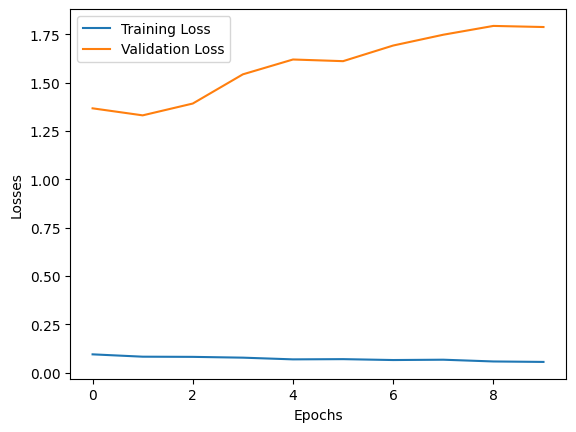

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses
})

plt.plot(loss_df["Training Loss"],label = "Training Loss")
plt.plot(loss_df["Validation Loss"],label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
plt.show()

In [41]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [42]:
# Evaluate our CNN

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images,labels in test_loader:
        outputs = model.forward(images)
        _,predicted = torch.max(outputs,1) # this will give maximum value in _ and there index in predicted and max value index will be our predicted output

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {(correct_labels/total_labels)*100 }")

accuracy = 75.35
